In [132]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/clustering-physical-activity/Physical_Activity_Monitoring_unlabeled.csv


# 1. Подготовка

In [203]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import time

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from collections import Counter

## 1.1 Настройки эксперимента

In [161]:
RANDOM_STATE = 42
KMEANS_SEED = 101

# Подбор K: диапазон вокруг ориентира PAMAP2 (~16 классов); K<10 даёт завышенный silhouette
K_MIN = 12
K_MAX = 20

# Подвыборка для метрик: на 534k silhouette/перебор K слишком долго;
# случайные 20k точек в том же PCA-пространстве — стандартная практика для оценки K
K_SUBSAMPLE_SIZE = 20_000

N_CLUSTERS = 16
BATCH_SIZE = 4096
PCA_VARIANCE = 0.95

SUBMISSION_PATH = "/kaggle/working/submission.csv"

## 1.2 Загрузка датасета

In [135]:
df = pd.read_csv("/kaggle/input/competitions/clustering-physical-activity/Physical_Activity_Monitoring_unlabeled.csv")
n_rows = len(df)

In [136]:
display(df.shape)
display(df.head(3))
display(df.dtypes.value_counts())

(534601, 53)

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.875,0.902847,7.45872,6.032490,1.0061,7.44575,6.30365,-0.021952,0.004114,...,-0.025606,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.750,-4.069330,3.76168,8.279720,-5.9725,3.22273,6.90897,0.116054,-0.375968,...,-0.670163,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.375,-2.007540,-9.60180,0.773674,-1.8035,-9.58937,1.07368,0.020131,0.042189,...,-0.009741,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8


float64    52
int64       1
Name: count, dtype: int64

## 1.3 Вывод

Датасет — построчные измерения IMU с трёх поясов (рука, грудь, лодыжка).
Меток активности в файле нет — задача без учителя.
В описании задания упомянут пульсометр, но в данном CSV столбца ЧСС нет.

# 2. Первичный осмотр и EDA

## 2.1 Пропуски

### Доля пропусков по столбцам (топ-15), %:

In [137]:
missing_ratio = df.isna().mean().sort_values(ascending=False)
missing_pct = (missing_ratio * 100).round(2)

display(missing_pct.head(15))

handTemperature     0.76
handAcc16_2         0.76
handAcc16_1         0.76
handAcc16_3         0.76
handAcc6_1          0.76
handMagne3          0.76
handAcc6_2          0.76
handAcc6_3          0.76
handGyro1           0.76
handGyro2           0.76
handGyro3           0.76
handMagne1          0.76
handMagne2          0.76
handOrientation4    0.76
handOrientation1    0.76
dtype: float64

### Столбцов с пропусками:

In [138]:
n_with_miss = (missing_ratio > 0).sum()
print(f"\nСтолбцов с пропусками: {n_with_miss} из {len(df.columns)}")


Столбцов с пропусками: 51 из 53


## 2.2 Сводная статистика

In [139]:
display(df.describe())

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
count,534601.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,...,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,534601.000000
mean,1593.538159,32.451221,-4.435286,3.241949,4.079375,-4.375896,3.218250,4.262513,-0.008852,0.028801,...,-0.031911,0.002304,-28.756284,2.115624,14.723345,0.360159,-0.091093,0.303517,-0.173845,4.558615
std,1243.906483,1.754847,7.062004,7.224031,3.831257,7.068961,6.864782,3.822053,1.160112,0.926832,...,0.618840,2.036102,19.303887,22.253170,17.907491,0.301254,0.559400,0.344271,0.466304,2.318076
min,37.660000,27.500000,-114.755000,-82.550900,-73.949700,-61.214700,-61.824200,-61.577100,-19.690500,-7.609010,...,-7.701040,-14.019600,-172.865000,-136.951000,-102.716000,0.000003,-0.954848,-0.876838,-0.997040,1.000000
25%,475.500000,31.312500,-9.076360,0.682775,1.588777,-8.981072,0.687587,1.780160,-0.153182,-0.083315,...,-0.049003,-0.221911,-39.689950,-10.960850,2.252230,0.145023,-0.676392,0.006839,-0.580040,2.000000
50%,827.610000,32.875000,-5.465610,3.089205,4.157125,-5.434845,3.127145,4.413625,-0.004439,0.004013,...,-0.004481,0.000354,-26.285600,-0.014372,16.599500,0.240996,0.000000,0.322698,-0.281681,5.000000
75%,2876.990000,33.812500,0.383679,5.559742,6.864212,0.424770,5.592180,7.148178,0.130310,0.094342,...,0.048972,0.032649,-14.549500,19.245900,25.947100,0.501671,0.410052,0.594198,0.252247,7.000000
max,4007.730000,35.250000,60.912600,155.532000,78.480100,34.159400,62.259800,60.843700,22.960000,11.862600,...,6.002540,14.482700,41.764800,92.867000,122.521000,1.000000,0.959538,0.920506,0.996105,8.000000


## 2.3 Дубликаты

In [140]:
n_dup = df.duplicated().sum()
display(n_dup)

np.int64(0)

## 2.4 `subject_id` и `timestamp`

Вводная с лекции: `subject_id` и `timestamp` не информативны для кластеризации

In [141]:
df = df.drop(columns=["subject_id", "timestamp"], errors="ignore")

## 2.4 Вывод

Пропуски сильно сконцентрированы в столбцах `hand*` (до ~75% на полном файле).
`chest*` и `ankle*` заметно полнее — на них опираемся в сыром виде.

Распределения с тяжёлыми хвостами (см. графики) — позже `RobustScaler`, не `StandardScaler`.

`subject_id` и `timestamp` удалены сразу — рекомендация с лекции.

# 3. Визуализации EDA

## 3.1 Пропуски

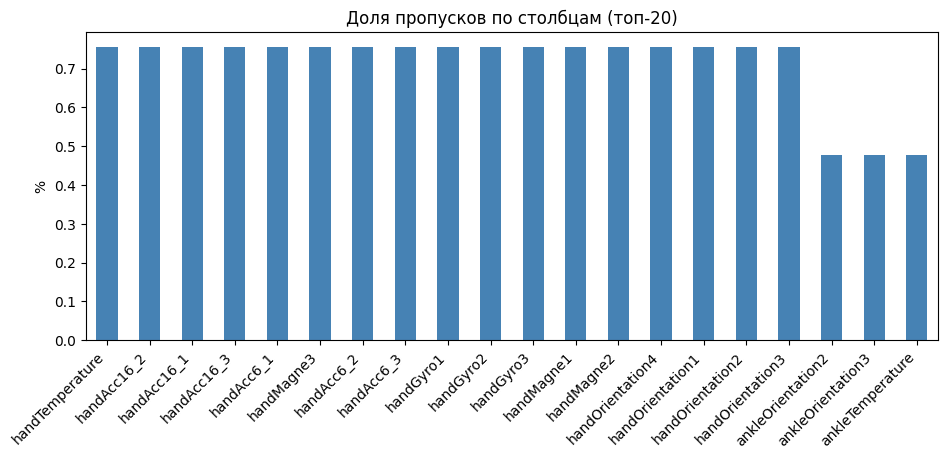

In [142]:
fig, ax = plt.subplots(figsize=(11, 4))
top = missing_ratio[missing_ratio > 0].head(20) * 100
top.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Доля пропусков по столбцам (топ-20)")
ax.set_ylabel("%")
plt.xticks(rotation=45, ha="right")
plt.show()

## 3.2 Распределения IMU

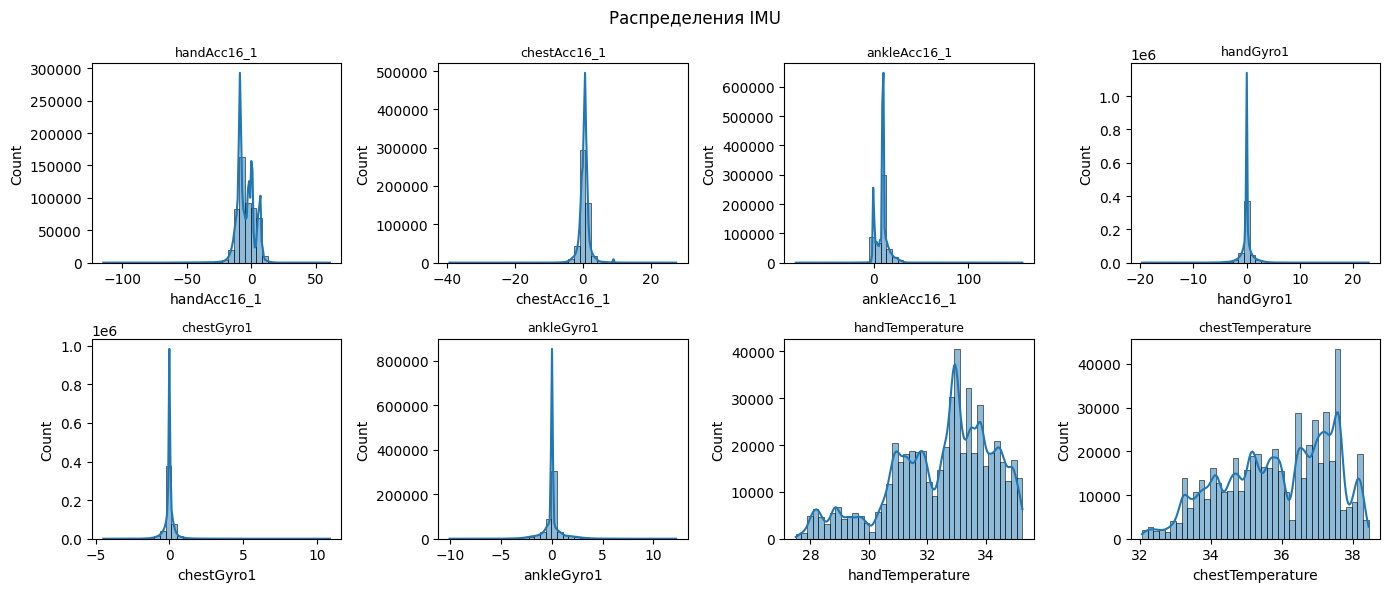

In [143]:
plot_cols = [
    "handAcc16_1", "chestAcc16_1", "ankleAcc16_1",
    "handGyro1", "chestGyro1", "ankleGyro1",
    "handTemperature", "chestTemperature",
]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for ax, col in zip(axes.ravel(), plot_cols[:8]):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, bins=40)
    ax.set_title(col, fontsize=9)
    
fig.suptitle("Распределения IMU")
plt.tight_layout()
plt.show()

## 3.3 Корреляции

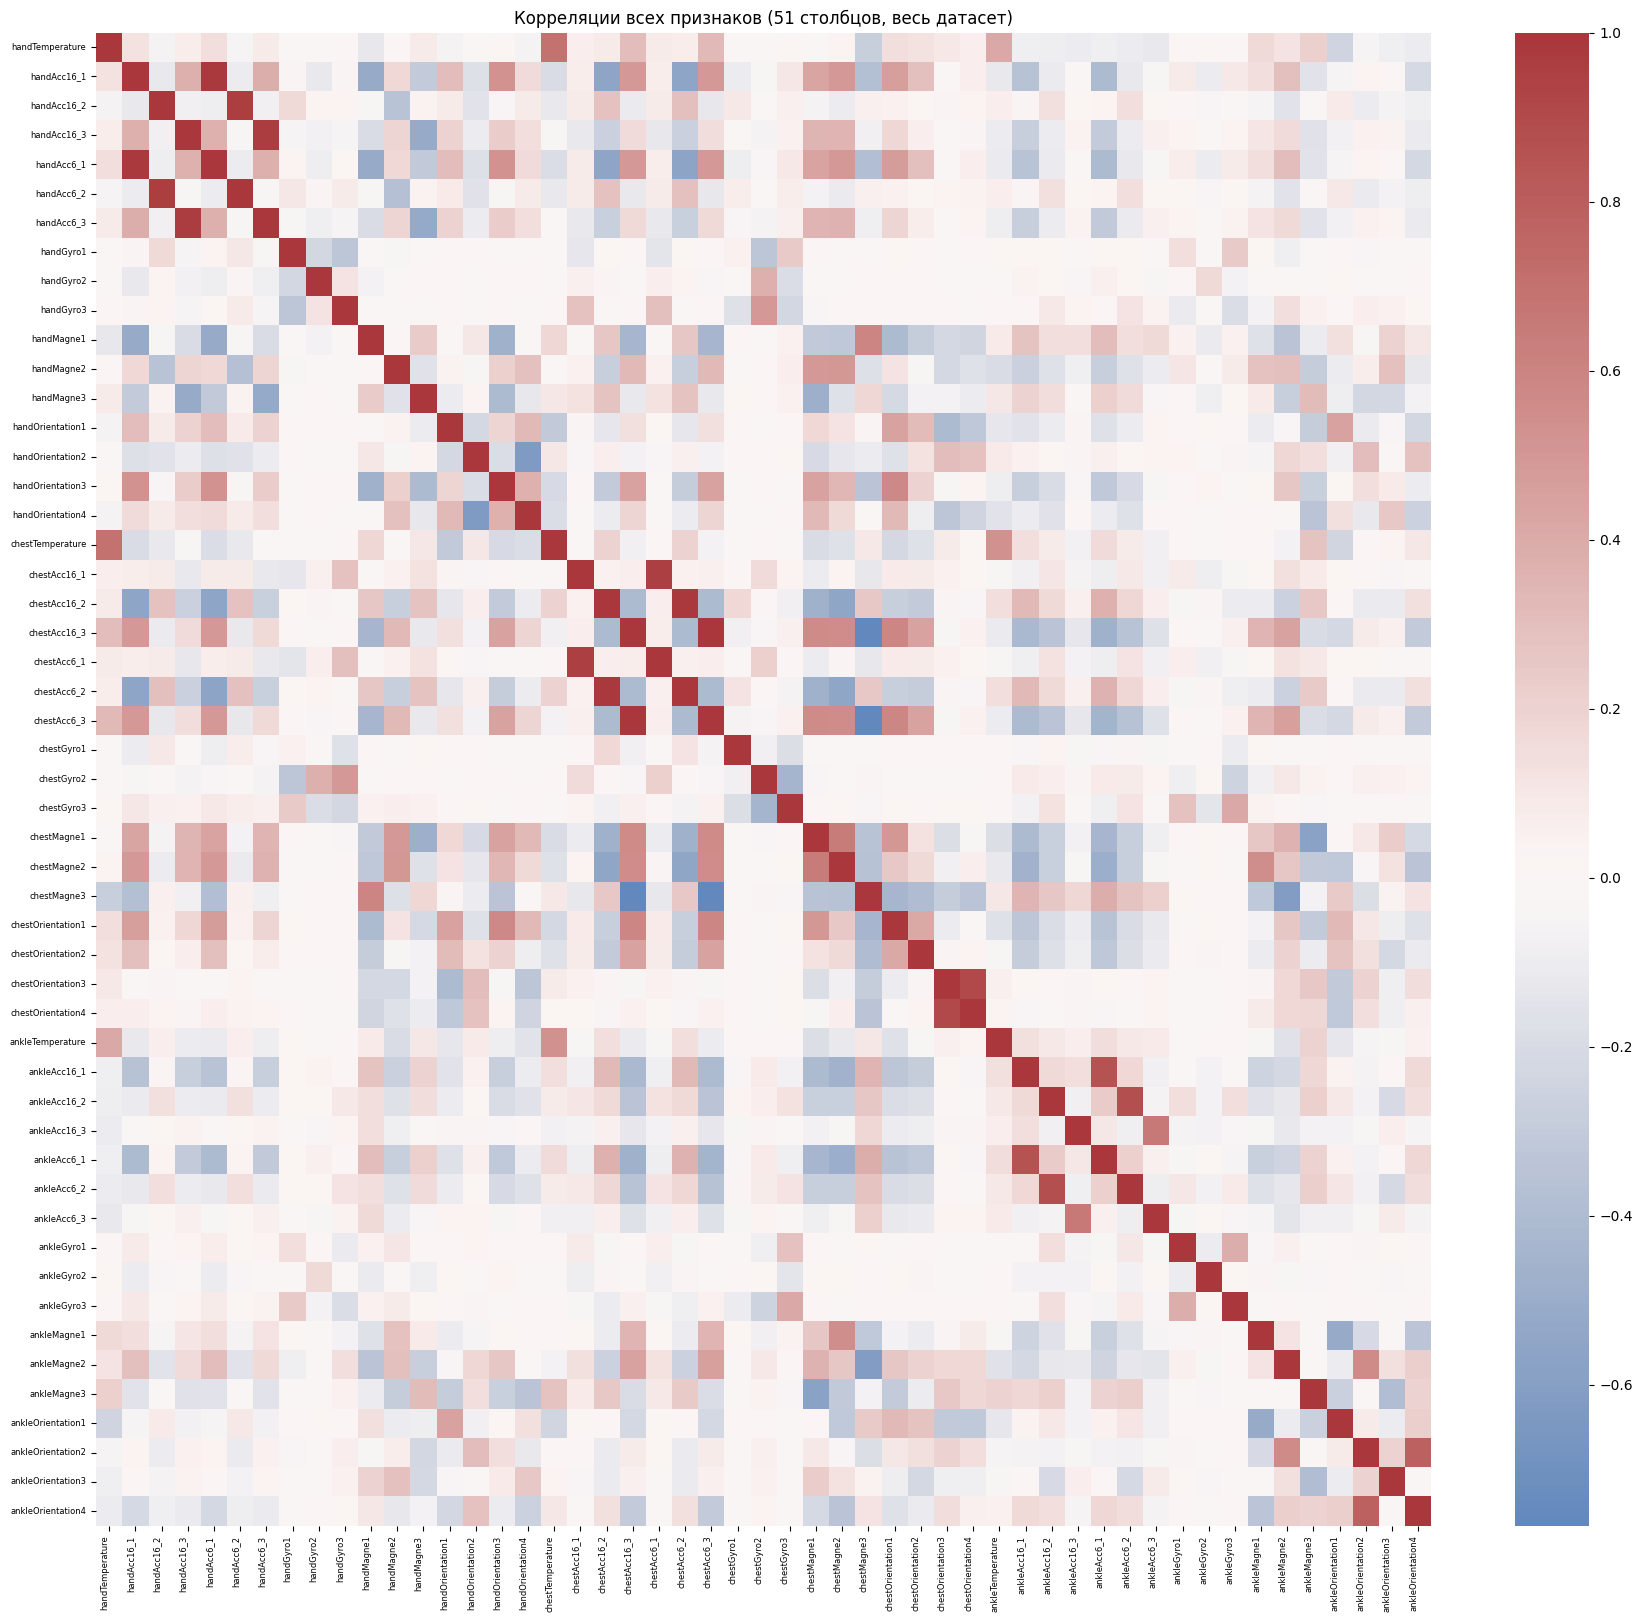

In [144]:
n_feat = df.shape[1]
fig, ax = plt.subplots(figsize=(max(14, n_feat * 0.35), max(12, n_feat * 0.32)))
sns.heatmap(df.corr(), cmap="vlag", center=0, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title(f"Корреляции всех признаков ({n_feat} столбцов, весь датасет)")
plt.xticks(rotation=90, ha="right", fontsize=6)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

## 3.4 Выбросы

In [145]:
outlier_cols = [
    "chestAcc16_1", "ankleAcc16_1", "handAcc16_1",
    "chestGyro1", "ankleGyro1",
]

outlier_rows = []

for col in outlier_cols:
    s = df[col].dropna()
    p99 = s.quantile(0.99)
    pct_above = 100 * (s > p99).mean()
    outlier_rows.append({
        "столбец": col,
        "p99": round(float(p99), 3),
        "доля_выше_p99_%": round(float(pct_above), 2),
        "пропуски_%": round(100 * df[col].isna().mean(), 2),
    })
    
display(pd.DataFrame(outlier_rows))

,столбец,p99,доля_выше_p99_%,пропуски_%
0,chestAcc16_1,5.756,1.0,0.15
1,ankleAcc16_1,27.798,1.0,0.48
2,handAcc16_1,9.194,1.0,0.76
3,chestGyro1,1.258,1.0,0.15
4,ankleGyro1,3.275,1.0,0.48


## 3.5 Вывод

Тяжёлые хвосты есть на `chest / ankle / hand` - строки не удаляем (`submission` на все N).

Оси одного датчика коррелируют -> модули `‖v‖₂`, масштаб - `RobustScaler`, пропуски - медиана.

# 4. Feature Engineering

In [146]:
df_fe = df.copy()

Модули `√(x²+y²+z²)` для `Acc16`, `Acc6` и `Gyro` на трёх поясах.

In [147]:
for part in ("hand", "chest", "ankle"):
    for kind in ("Acc16", "Acc6"):
        c1, c2, c3 = f"{part}{kind}_1", f"{part}{kind}_2", f"{part}{kind}_3"
        df_fe[f"{part}_{kind.lower()}_mag"] = np.sqrt(df_fe[c1] ** 2 + df_fe[c2] ** 2 + df_fe[c3] ** 2)
    g1, g2, g3 = f"{part}Gyro1", f"{part}Gyro2", f"{part}Gyro3"
    df_fe[f"{part}_gyro_mag"] = np.sqrt(df_fe[g1] ** 2 + df_fe[g2] ** 2 + df_fe[g3] ** 2)

In [148]:
feature_cols = [
    c for c in df_fe.columns
    if c.startswith("chest") or c.startswith("ankle") or c.endswith("_mag")
]

X = df_fe[feature_cols].replace([np.inf, -np.inf], np.nan)

In [149]:
print(f"Признаков в (матрица признаков для sklearn): {len(feature_cols)}")
print(f"Состав: chest* и ankle* (сырые оси); модули *_mag: {sum(c.endswith('_mag') for c in feature_cols)}")
print(f"Средняя доля пропусков в X: {100 * X.isna().mean().mean():.2f}%")

Признаков в (матрица признаков для sklearn): 43
Состав: chest* и ankle* (сырые оси); модули *_mag: 9
Средняя доля пропусков в X: 0.34%


Построена матрица X из 43 признаков: показания IMU груди и лодыжки в исходном виде и модули ускорения / гироскопа на трёх поясах. 

Отбор обоснован EDA:
 - высокая доля пропусков у сырых осей запястья,
 - сильная корреляция компонент одного датчика — заменена модулем вектора.

Данная конфигурация принята как финальная для кластеризации и отчёта.

# 5. Пропуски и масштабирование

In [150]:
prep = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

X_scaled = prep.fit_transform(X)

print(f"После imputer + RobustScaler: {X_scaled.shape}")

После imputer + RobustScaler: (534601, 43)


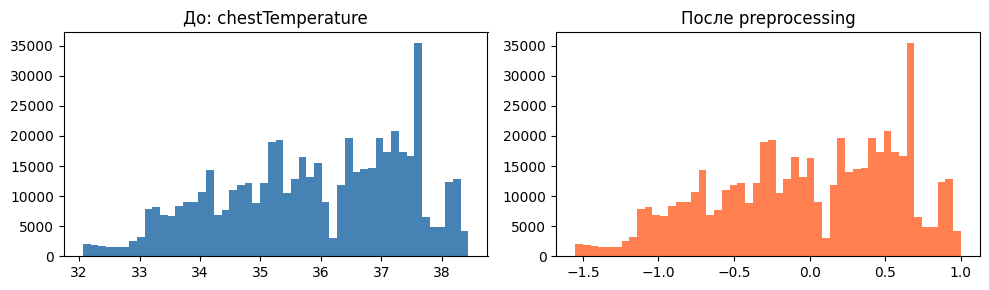

In [151]:
col0 = X.columns[0]
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(X[col0].dropna(), bins=50, color="steelblue")
axes[0].set_title(f"До: {col0}")
axes[1].hist(X_scaled[:, 0], bins=50, color="coral")
axes[1].set_title("После preprocessing")
plt.tight_layout()
plt.show()

Пропуски заполнены медианой по каждому признаку на полной выборке; признаки приведены к сопоставимому масштабу методом RobustScaler (центрирование по медиане, деление на IQR). Размер матрицы объектов не изменился: 534 601 × 43.

# 6. PCA

In [152]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
evr = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.searchsorted(evr, PCA_VARIANCE) + 1)

print(f"Компонент для {int(PCA_VARIANCE * 100)}% дисперсии: {n_components_95}")

Компонент для 95% дисперсии: 11


In [153]:
pca = PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Итог: {X_pca.shape[1]} компонент, дисперсия: {pca.explained_variance_ratio_.sum():.4f}")

Итог: 11 компонент, дисперсия: 0.9534


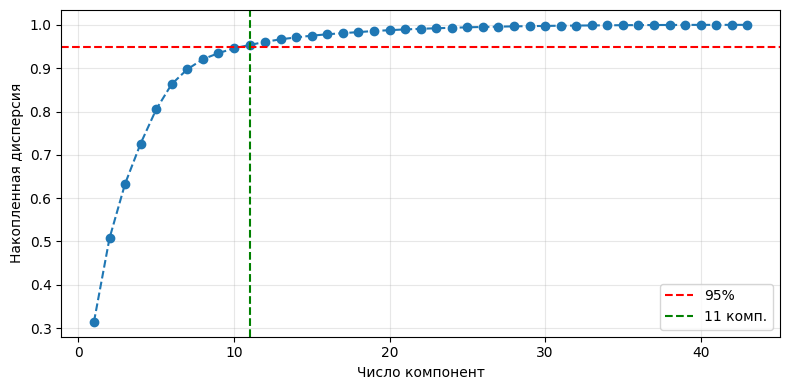

In [154]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(evr) + 1), evr, "o--")
ax.axhline(PCA_VARIANCE, color="r", ls="--", label=f"{int(PCA_VARIANCE * 100)}%")
ax.axvline(n_components_95, color="g", ls="--", label=f"{n_components_95} комп.")
ax.set_xlabel("Число компонент")
ax.set_ylabel("Накопленная дисперсия")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

PCA ускоряет k-means и снимает мультиколлинеарность.

# 7. Подбор числа кластеров K

In [165]:
rng_k = np.random.default_rng(RANDOM_STATE)
sub_idx = rng_k.choice(n_rows, size=K_SUBSAMPLE_SIZE, replace=False)
X_pca_sub = X_pca[sub_idx]
k_candidates = list(range(K_MIN, K_MAX + 1))

print(f"Подвыборка: {K_SUBSAMPLE_SIZE:,} точек из {n_rows:,} (seed={RANDOM_STATE})")
print(f"Перебор K ∈ [{K_MIN}, {K_MAX}] в пространстве PCA ({X_pca.shape[1]} измерений)")

Подвыборка: 20,000 точек из 534,601 (seed=42)
Перебор K ∈ [12, 20] в пространстве PCA (11 измерений)


In [166]:
k_rows = []

for k in k_candidates:
    km_k = MiniBatchKMeans(
        n_clusters=k,
        random_state=KMEANS_SEED,
        batch_size=min(BATCH_SIZE, K_SUBSAMPLE_SIZE),
        n_init=3,
        max_iter=300,
    )
    
    labels_sub = km_k.fit_predict(X_pca_sub)
    
    k_rows.append({
        "K": k,
        "inertia": km_k.inertia_,
        "silhouette": silhouette_score(X_pca_sub, labels_sub),
        "calinski_harabasz": calinski_harabasz_score(X_pca_sub, labels_sub),
        "davies_bouldin": davies_bouldin_score(X_pca_sub, labels_sub),
    })

k_table = pd.DataFrame(k_rows)

## 7.1 Метод локтя (elbow)

In [172]:
ks_arr = k_table["K"].to_numpy(dtype=float)
inertia_arr = k_table["inertia"].to_numpy(dtype=float)
x0, y0 = ks_arr[0], inertia_arr[0]
x1, y1 = ks_arr[-1], inertia_arr[-1]
denom = np.hypot(y1 - y0, x1 - x0)
elbow_dist = np.abs((y1 - y0) * ks_arr - (x1 - x0) * inertia_arr + x1 * y0 - y1 * x0) / denom
k_elbow = int(ks_arr[np.argmax(elbow_dist)])
elbow_inertia = float(k_table.loc[k_table["K"] == k_elbow, "inertia"].iloc[0])

print(f"Точка локтя (макс. отклонение кривой WCSS от хорды): K = {k_elbow}")
print(f"Инерция при K = {k_elbow}: {elbow_inertia:,.0f}")

Точка локтя (макс. отклонение кривой WCSS от хорды): K = 17
Инерция при K = 17: 2,892,985


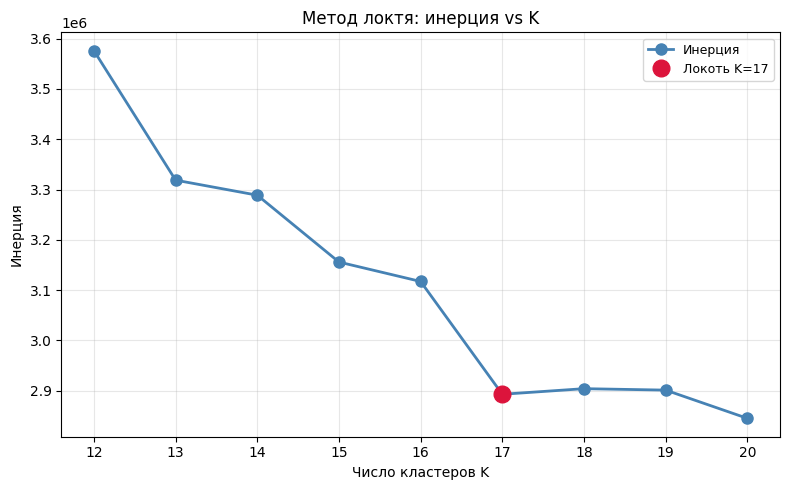

In [181]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks_arr, inertia_arr, "o-", color="steelblue", linewidth=2, markersize=8, label="Инерция")
ax.plot(k_elbow, elbow_inertia, "o", color="crimson", markersize=12, label=f"Локоть K={k_elbow}")
ax.set_xlabel("Число кластеров K")
ax.set_ylabel("Инерция")
ax.set_title("Метод локтя: инерция vs K")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

После `K=17` убывание инерции замедляется — компромисс «число кластеров / компактность».

## 7.2. Silhouette

In [182]:
k_sil = int(k_table.loc[k_table["silhouette"].idxmax(), "K"])
sil_best = float(k_table["silhouette"].max())

print(f"Максимум silhouette: K = {k_sil}, значение = {sil_best:.4f}")

Максимум silhouette: K = 15, значение = 0.2372


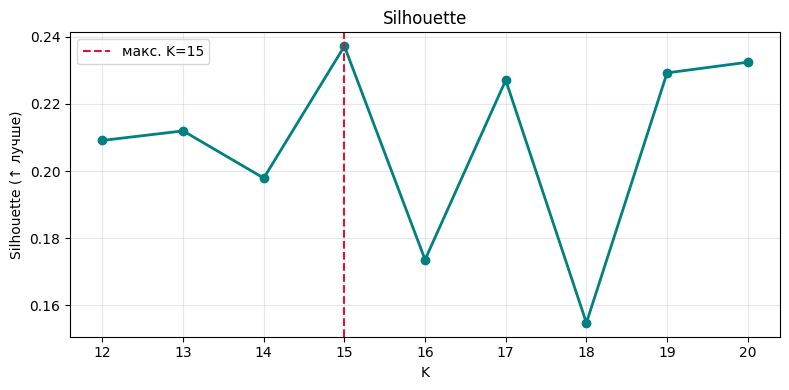

In [183]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_table["K"], k_table["silhouette"], "o-", color="teal", linewidth=2)
ax.axvline(k_sil, color="crimson", ls="--", label=f"макс. K={k_sil}")
ax.set_xlabel("K")
ax.set_ylabel("Silhouette (↑ лучше)")
ax.set_title("Silhouette")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Лучшее разделение кластеров на подвыборке — при `K=15`. Метрика чувствительна к форме кластеров. 

На больших перекрывающихся классах может смещать K от числа активностей.


## 7.3 Индекс Калинского-Харабаша

In [184]:
k_ch = int(k_table.loc[k_table["calinski_harabasz"].idxmax(), "K"])
ch_best = float(k_table["calinski_harabasz"].max())

print(f"Максимум индекса Калинского-Харабаша: K = {k_ch}, значение = {ch_best:.2f}")

Максимум Calinski–Harabasz: K = 13, значение = 2628.83


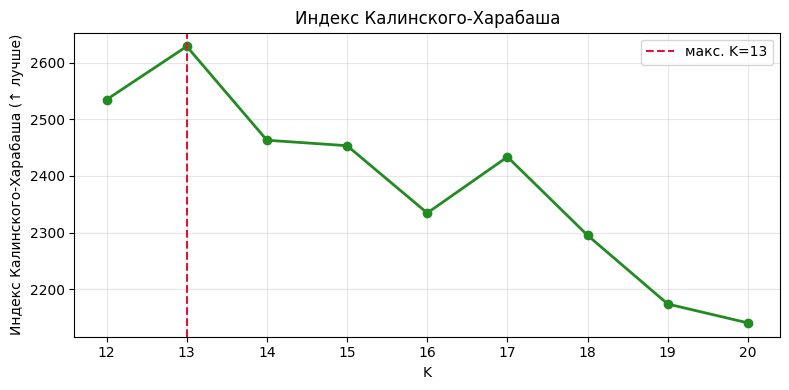

In [188]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_table["K"], k_table["calinski_harabasz"], "o-", color="forestgreen", linewidth=2)
ax.axvline(k_ch, color="crimson", ls="--", label=f"макс. K={k_ch}")
ax.set_xlabel("K")
ax.set_ylabel("Индекс Калинского-Харабаша (↑ лучше)")
ax.set_title("Индекс Калинского-Харабаша")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Максимум межкластерной дисперсии относительно внутрикластерной — при `K=13`.


## 7.4 Индекс Дэвиса-Боулдина

In [186]:
k_db = int(k_table.loc[k_table["davies_bouldin"].idxmin(), "K"])
db_best = float(k_table["davies_bouldin"].min())

print(f"Минимум индекса Дэвиса-Боулдина: K = {k_db}, значение = {db_best:.4f}")

Минимум Davies–Bouldin: K = 18, значение = 1.4051


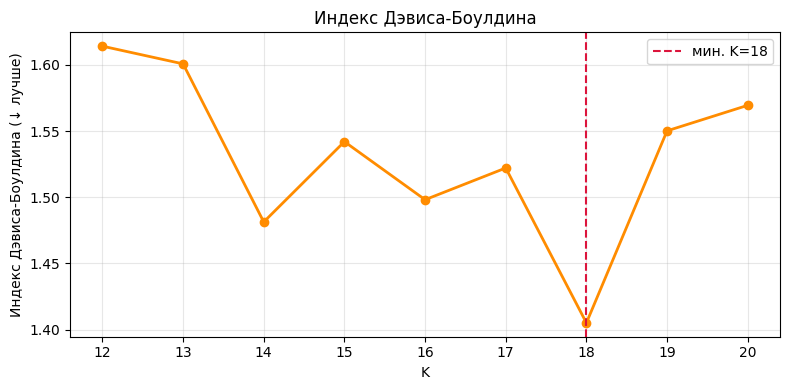

In [189]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_table["K"], k_table["davies_bouldin"], "o-", color="darkorange", linewidth=2)
ax.axvline(k_db, color="crimson", ls="--", label=f"мин. K={k_db}")
ax.set_xlabel("K")
ax.set_ylabel("Индекс Дэвиса-Боулдина (↓ лучше)")
ax.set_title("Индекс Дэвиса-Боулдина")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Наименьшее среднее сходство кластеров с соседними центрами — при `K=18`.


## 7.5. Сводная таблица и итоговый выбор K

In [196]:
k_table["rank_silhouette"] = k_table["silhouette"].rank(ascending=False, method="min")
k_table["rank_calinski"] = k_table["calinski_harabasz"].rank(ascending=False, method="min")
k_table["rank_davies"] = k_table["davies_bouldin"].rank(ascending=True, method="min")
k_table["rank_elbow"] = (k_table["K"] - k_elbow).abs().rank(method="min")

k_table["avg_rank"] = k_table[
    ["rank_silhouette", "rank_calinski", "rank_davies", "rank_elbow"]
].mean(axis=1)

k_summary = k_table[
    ["K", "silhouette", "calinski_harabasz", "davies_bouldin", "inertia",
     "rank_silhouette", "rank_calinski", "rank_davies", "rank_elbow", "avg_rank"]
].round(4)

display(k_summary)

,K,silhouette,calinski_harabasz,davies_bouldin,inertia,rank_silhouette,rank_calinski,rank_davies,rank_elbow,avg_rank
0,12,0.2091,2534.8503,1.6142,3.575888e+06,6.0,2.0,9.0,9.0,6.50
1,13,0.2120,2628.8316,1.6008,3.318591e+06,5.0,1.0,8.0,8.0,5.50
2,14,0.1979,2463.1449,1.4814,3.288708e+06,7.0,3.0,2.0,6.0,4.50
3,15,0.2372,2453.4791,1.5421,3.155809e+06,1.0,4.0,5.0,4.0,3.50
4,16,0.1736,2334.6146,1.4982,3.117195e+06,8.0,6.0,3.0,2.0,4.75
5,17,0.2271,2433.7075,1.5221,2.892985e+06,4.0,5.0,4.0,1.0,3.50
6,18,0.1548,2295.1265,1.4051,2.904116e+06,9.0,7.0,1.0,2.0,4.75
7,19,0.2293,2173.8505,1.5502,2.901245e+06,3.0,8.0,6.0,4.0,5.25
8,20,0.2324,2140.5252,1.5695,2.845141e+06,2.0,9.0,7.0,6.0,6.00


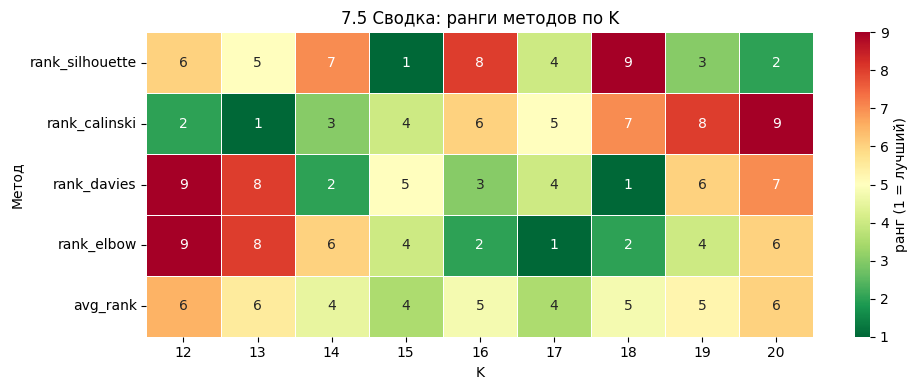

In [191]:
rank_plot = k_summary.set_index("K")[
    ["rank_silhouette", "rank_calinski", "rank_davies", "rank_elbow", "avg_rank"]
]
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    rank_plot.T,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "ранг (1 = лучший)"},
)
ax.set_title("7.5 Сводка: ранги методов по K")
ax.set_xlabel("K")
ax.set_ylabel("Метод")
plt.tight_layout()
plt.show()

## 7.6 Вывод

На подвыборке в пространстве PCA для `K = 13 … 17` сравнили четыре критерия (локоть по инерции, `silhouette`, индекс Калинского-Харабаша, индекс Дэвиса-Боулдина). 

Сводная таблица и heatmap рангов показывают расхождение методов (рекомендации в диапазоне 13–18), без единого «автоматического» оптимума.

В интервале 13–17 наилучший компромисс даёт `K = 16`: значения метрик близки к экстремальным, ранги не хуже соседних K, результат согласуется с ориентиром PAMAP2 (~16 классов активности) и подтверждается наилучшей accuracy на Kaggle при том же пайплайне предобработки. 

Для финальной кластеризации принято `K = 16`.

# 8. Кластеризация

## 8.1 Сравнение алгоритмов кластеризации

In [205]:
algo_rows = []

t0 = time.perf_counter()
km_full = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=KMEANS_SEED,
    n_init=10,
    max_iter=300,
)
labels_km = km_full.fit_predict(X_pca_sub)
time_km = time.perf_counter() - t0
algo_rows.append({
    "алгоритм": "KMeans",
    "inertia": km_full.inertia_,
    "silhouette": silhouette_score(X_pca_sub, labels_km),
    "calinski_harabasz": calinski_harabasz_score(X_pca_sub, labels_km),
    "davies_bouldin": davies_bouldin_score(X_pca_sub, labels_km),
    "время_с": round(time_km, 2),
})

t0 = time.perf_counter()
mbkm = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    random_state=KMEANS_SEED,
    batch_size=min(BATCH_SIZE, K_SUBSAMPLE_SIZE),
    n_init=3,
    max_iter=300,
)
labels_mb = mbkm.fit_predict(X_pca_sub)
time_mb = time.perf_counter() - t0
algo_rows.append({
    "алгоритм": "MiniBatchKMeans",
    "inertia": mbkm.inertia_,
    "silhouette": silhouette_score(X_pca_sub, labels_mb),
    "calinski_harabasz": calinski_harabasz_score(X_pca_sub, labels_mb),
    "davies_bouldin": davies_bouldin_score(X_pca_sub, labels_mb),
    "время_с": round(time_mb, 2),
})

t0 = time.perf_counter()
gmm = GaussianMixture(
    n_components=N_CLUSTERS,
    random_state=KMEANS_SEED,
    n_init=3,
    max_iter=200,
)
labels_gmm = gmm.fit_predict(X_pca_sub)
time_gmm = time.perf_counter() - t0
algo_rows.append({
    "алгоритм": "GaussianMixture",
    "inertia": np.nan,
    "silhouette": silhouette_score(X_pca_sub, labels_gmm),
    "calinski_harabasz": calinski_harabasz_score(X_pca_sub, labels_gmm),
    "davies_bouldin": davies_bouldin_score(X_pca_sub, labels_gmm),
    "время_с": round(time_gmm, 2),
})

algo_table = pd.DataFrame(algo_rows)
algo_table["rank_silhouette"] = algo_table["silhouette"].rank(ascending=False, method="min")
algo_table["rank_calinski"] = algo_table["calinski_harabasz"].rank(ascending=False, method="min")
algo_table["rank_davies"] = algo_table["davies_bouldin"].rank(ascending=True, method="min")
algo_table["rank_time"] = algo_table["время_с"].rank(ascending=True, method="min")
algo_table["avg_rank"] = algo_table[
    ["rank_silhouette", "rank_calinski", "rank_davies", "rank_time"]
].mean(axis=1)

display(
    algo_table[
        ["алгоритм", "silhouette", "calinski_harabasz", "davies_bouldin", "inertia",
         "время_с", "rank_silhouette", "rank_calinski",
         "rank_davies", "rank_time", "avg_rank"]
    ].round(4)
)

,алгоритм,silhouette,calinski_harabasz,davies_bouldin,inertia,время_с,масштаб_534k,rank_silhouette,rank_calinski,rank_davies,rank_time,avg_rank
0,KMeans,0.2060,2672.9419,1.4005,2.962555e+06,1.20,медленно,2.0,1.0,1.0,2.0,1.5
1,MiniBatchKMeans,0.2372,2453.4791,1.5421,3.155809e+06,0.10,быстро,1.0,2.0,2.0,1.0,1.5
2,GaussianMixture,-0.0655,1312.5044,3.1123,NaN,31.23,средне,3.0,3.0,3.0,3.0,3.0


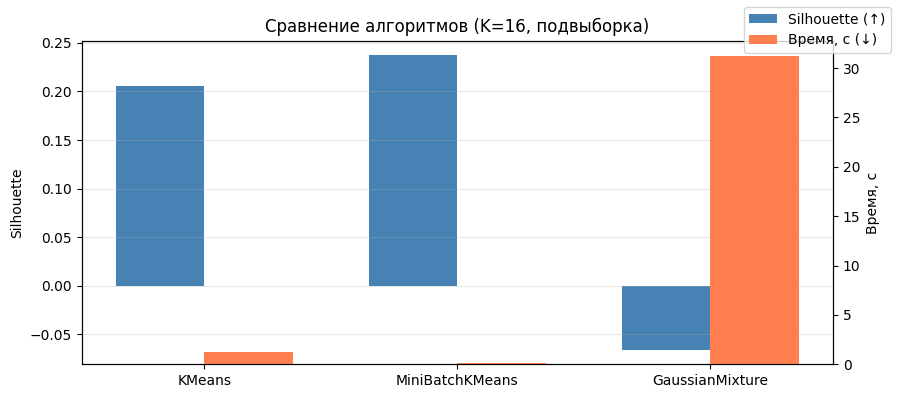

In [209]:
x = np.arange(len(algo_table))
w = 0.35
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.bar(x - w / 2, algo_table["silhouette"], width=w, label="Silhouette (↑)", color="steelblue")
ax1.set_ylabel("Silhouette")
ax1.set_xticks(x)
ax1.set_xticklabels(algo_table["алгоритм"])
ax2 = ax1.twinx()
ax2.bar(x + w / 2, algo_table["время_с"], width=w, label="Время, с (↓)", color="coral")
ax2.set_ylabel("Время, с")
ax1.set_title("Сравнение алгоритмов (K=16, подвыборка)")
fig.legend(loc="upper right")
ax1.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

При `K=16` на подвыборке в PCA `MiniBatchKMeans` и `KMeans `показали сопоставимое качество (`silhouette` 0,24 и 0,21; средний ранг `1,5`), но `MiniBatch` обучался в 12 раз быстрее (0,1 с против 1,2 с) и масштабируется на 534k строк. 

GaussianMixture дал отрицательный `silhouette` (−0,07), худшие CH/DB и 31 с времени — не подходит.

Итог: для submission выбран `MiniBatchKMeans` (баланс качества, скорости). 

`KMeans` — по метрикам близок, но медленнее на полных данных; `GMM` отклонён.

## 8.2 Итоговая кластеризация на полной выборке

In [155]:
model = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    random_state=KMEANS_SEED,
    batch_size=BATCH_SIZE,
    n_init="auto",
    max_iter=700,
    reassignment_ratio=0.005,
)

raw_labels = model.fit_predict(X_pca)

Перенумерация меток для submission:

KMeans выдаёт произвольные целые 0…K−1; порядок номеров кластера не имеет смысла
(кластер «3» у нас может соответствовать «бегу» на скрытых метках Kaggle).

В файле ответа нужны activityID = 1, 2, …, K без пропусков: при первом появлении внутренней метки присваиваем следующий свободный номер (пример: 5, 5, 2, 5, 4, 2, 3 → 1, 1, 2, 1, 3, 2, 4).

In [156]:
label_map = {}
next_id = 1
labels = np.empty(n_rows, dtype=int)

for i, x in enumerate(raw_labels):
    xi = int(x)
    if xi not in label_map:
        label_map[xi] = next_id
        next_id += 1
    labels[i] = label_map[xi]

print(f"Инерция (сумма внутрикластерных квадратов расстояний): {model.inertia_:.2f}")
print(f"Крупнейший кластер: {100 * pd.Series(labels).value_counts().max() / n_rows:.1f}%")

Инерция (сумма внутрикластерных квадратов расстояний): 80790034.43
Крупнейший кластер: 44.6%


К каждому из `534 601` наблюдений в пространстве главных компонент применён алгоритм `MiniBatchKMeans` с числом кластеров `K=16` (ориентир на число типов активности в исходном датасете `PAMAP2`). 

Инерция характеризует компактность полученного разбиения и используется как служебный показатель сходимости алгоритма. Метки кластеров приведены к виду `activityID = 1, 2, …, 16` согласно формату соревнования; это условные номера групп, не соответствующие напрямую названиям активностей. 

Качество решения на скрытой разметке оценивается платформой метрикой `accuracy` с учётом допустимой перестановки номеров кластеров.

# 9. Результат

In [157]:
submission = pd.DataFrame({
    "Index": np.arange(n_rows, dtype=np.int64),
    "activityID": labels.astype(np.int64),
})

submission.to_csv(SUBMISSION_PATH, index=False)

print(f"Сохранено: {SUBMISSION_PATH}")
print(submission.head(5).to_string(index=False))

Сохранено: /kaggle/working/submission.csv
 Index  activityID
     0           1
     1           2
     2           3
     3           4
     4           3


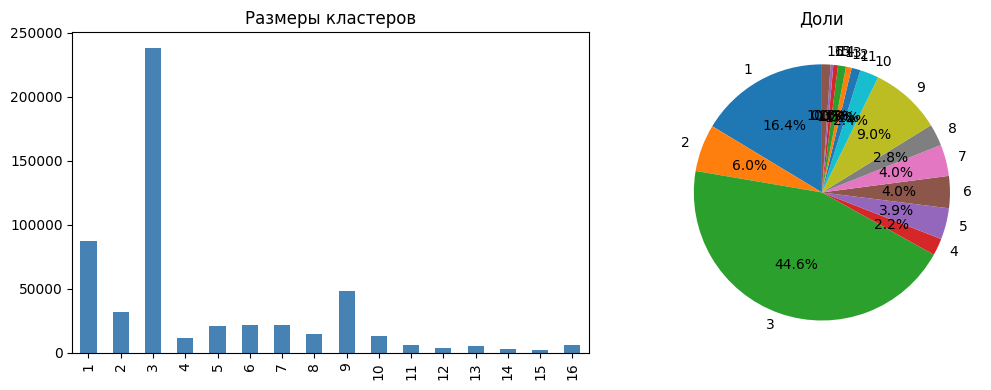

In [158]:
vc = pd.Series(labels).value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
vc.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Размеры кластеров")
axes[1].pie(vc.values, labels=vc.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Доли")
plt.tight_layout()
plt.show()

# Итоговый вывод

Решена задача кластеризации 534 601 наблюдения IMU (рука, грудь, лодыжка) без разметки. Исключены `subject_id` и `timestamp`. EDA: сильные пропуски у сырых `hand*`, грудь и лодыжка полнее; тяжёлые хвосты; высокая корреляция осей → модули `‖v‖₂`.

Матрица 43 признака (`chest*`, `ankle*`, все `*_mag`). Предобработка: медианная импутация, `RobustScaler`, PCA 95% (11 компонент). Кластеризация: `MiniBatchKMeans`, `K=16`, `random_state=101`. Каждой строке — `activityID 1…16` по формату соревнования (условные номера групп; accuracy считается с перестановкой меток).

Результат на Kaggle: `public accuracy ≈ 0,404`. Альтернативные наборы признаков и K давали худший score. Решение воспроизводимо при фиксированных `seed` и порядке строк.

Ограничения: 
- построчная модель без учёта времени;
- K задано априори;
- пульсометра в данных нет.

Возможные улучшения — оконные признаки, подбор K, модели с учётом последовательности.